In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("recipes_dataset.csv")
df.head()

,dishname,recipe_version,ingredients,cooking_time_min,difficulty,calories,user_reviews,taste_rating,health_rating,overall_rating
0,Butter Chicken,A,"Chicken, Butter, Tomato, Cream, Spices",45,Medium,520,1245,4.8,3.9,4.5
1,Butter Chicken,B,"Chicken, Yogurt, Tomato, Cream, Garlic",50,Medium,490,978,4.6,4.1,4.4
2,Butter Chicken,C,"Chicken, Cashew Paste, Tomato, Butter",55,Hard,560,756,4.9,3.7,4.6
3,Veg Fried Rice,A,"Rice, Carrot, Beans, Soy Sauce, Egg",25,Easy,320,654,4.3,4.2,4.3
4,Veg Fried Rice,B,"Brown Rice, Peas, Corn, Soy Sauce",30,Easy,290,488,4.1,4.7,4.4


In [6]:
df.shape

(27, 10)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dishname          27 non-null     str    
 1   recipe_version    27 non-null     str    
 2   ingredients       27 non-null     str    
 3   cooking_time_min  27 non-null     int64  
 4   difficulty        27 non-null     str    
 5   calories          27 non-null     int64  
 6   user_reviews      27 non-null     int64  
 7   taste_rating      27 non-null     float64
 8   health_rating     27 non-null     float64
 9   overall_rating    27 non-null     float64
dtypes: float64(3), int64(3), str(4)
memory usage: 2.2 KB


In [10]:
df.isnull().sum()

dishname            0
recipe_version      0
ingredients         0
cooking_time_min    0
difficulty          0
calories            0
user_reviews        0
taste_rating        0
health_rating       0
overall_rating      0
dtype: int64

In [12]:
df['dishname'].value_counts()

dishname
Butter Chicken     3
Veg Fried Rice     3
Paneer Tikka       3
Chicken Biryani    3
Caesar Salad       3
Masala Dosa        3
Pasta Alfredo      3
Grilled Salmon     3
Chocolate Cake     3
Name: count, dtype: int64

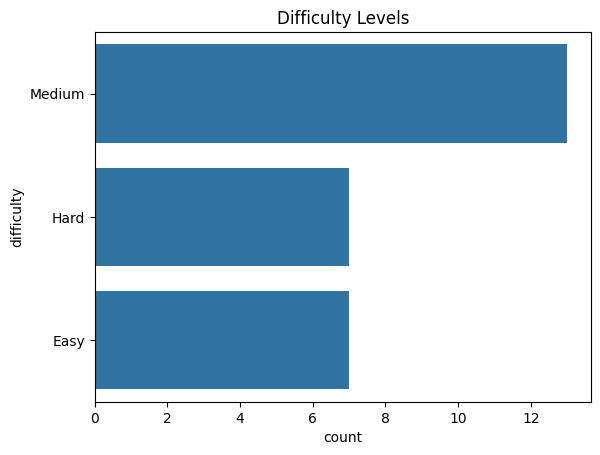

In [13]:
sns.countplot(df['difficulty'])
plt.title("Difficulty Levels")
plt.show()

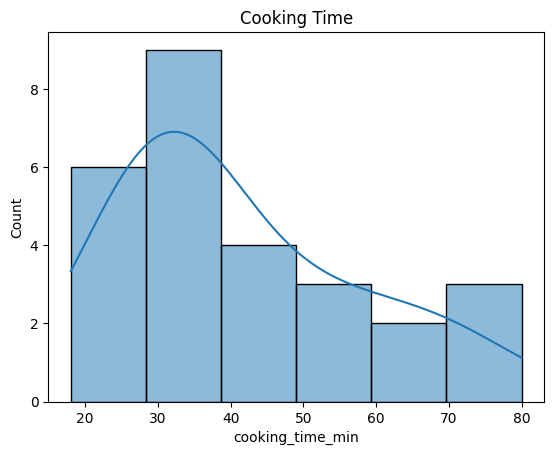

In [14]:
sns.histplot(df['cooking_time_min'],kde=True)
plt.title("Cooking Time")
plt.show()

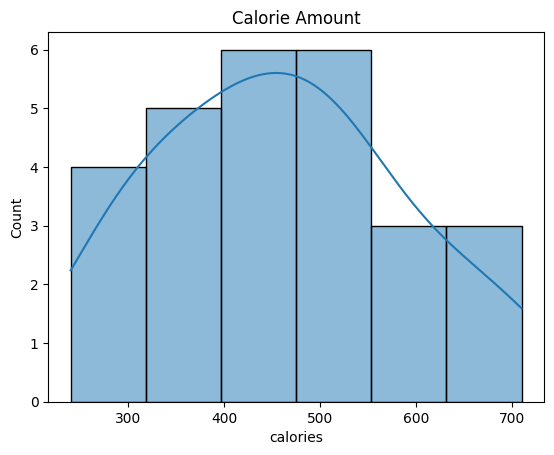

In [16]:
sns.histplot(df["calories"],kde=True)
plt.title("Calorie Amount")
plt.show()

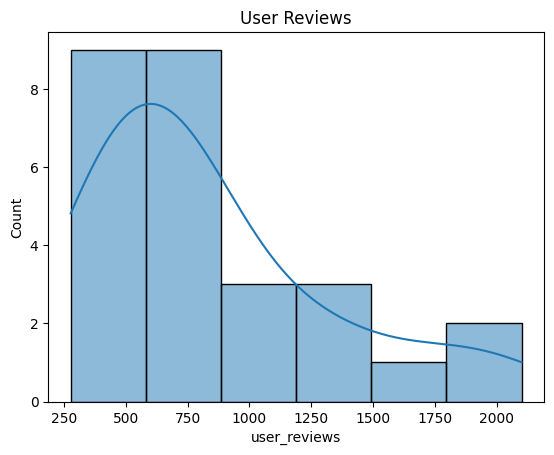

In [19]:
sns.histplot(df["user_reviews"],kde=True)
plt.title("User Reviews")
plt.show()

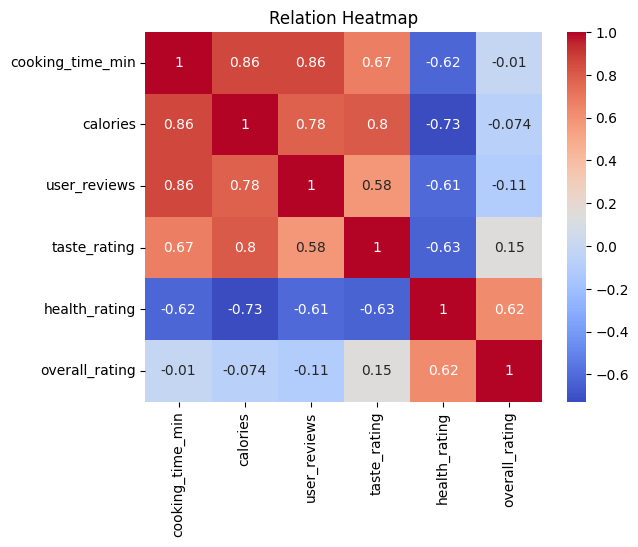

In [26]:
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm',annot=True)
plt.title("Relation Heatmap")
plt.show()

In [29]:
df.groupby('dishname')['overall_rating'].mean().sort_values(ascending=True)

dishname
Chocolate Cake     4.100000
Pasta Alfredo      4.200000
Veg Fried Rice     4.333333
Caesar Salad       4.400000
Masala Dosa        4.466667
Paneer Tikka       4.500000
Butter Chicken     4.500000
Chicken Biryani    4.633333
Grilled Salmon     4.800000
Name: overall_rating, dtype: float64

In [32]:
df.groupby('recipe_version')['overall_rating'].mean()

recipe_version
A    4.455556
B    4.455556
C    4.400000
Name: overall_rating, dtype: float64

In [39]:
df.groupby('dishname')['user_reviews'].mean().sort_values(ascending=False)

dishname
Chicken Biryani    1801.666667
Chocolate Cake     1330.000000
Butter Chicken      993.000000
Masala Dosa         781.666667
Pasta Alfredo       693.333333
Paneer Tikka        625.000000
Veg Fried Rice      577.333333
Grilled Salmon      381.333333
Caesar Salad        343.333333
Name: user_reviews, dtype: float64

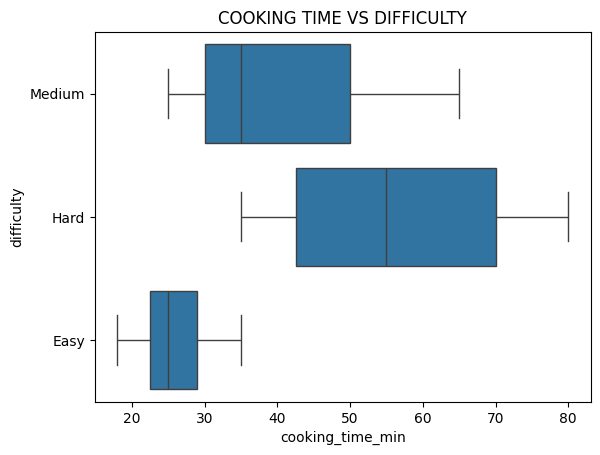

In [40]:
sns.boxplot(x='cooking_time_min',y='difficulty',data=df)
plt.title("COOKING TIME VS DIFFICULTY")
plt.show()

In [48]:
best_dish=df.loc[df.groupby('dishname')['overall_rating'].idxmax()]
best_dish[['dishname','taste_rating','overall_rating','ingredients']]

,dishname,taste_rating,overall_rating,ingredients
2,Butter Chicken,4.9,4.6,"Chicken, Cashew Paste, Tomato, Butter"
12,Caesar Salad,4.2,4.5,"Lettuce, Croutons, Chicken, Cheese"
9,Chicken Biryani,4.9,4.7,"Rice, Chicken, Onion, Spices"
25,Chocolate Cake,4.5,4.2,"Whole Wheat Flour, Cocoa, Honey"
21,Grilled Salmon,4.8,4.9,"Salmon, Lemon, Garlic, Herbs"
15,Masala Dosa,4.7,4.5,"Rice Batter, Potato, Onion, Spices"
6,Paneer Tikka,4.7,4.6,"Paneer, Yogurt, Spices, Capsicum"
19,Pasta Alfredo,4.2,4.3,"Whole Wheat Pasta, Milk, Herbs"
4,Veg Fried Rice,4.1,4.4,"Brown Rice, Peas, Corn, Soy Sauce"


# Summary

### The analysis clearly shows that the dataset is well balanced and offers strong insights into recipe performance
Each dish has variation and the analysis identifies the best recipe version based on the highest overall rating.
Making it suitable for:
Food Recommendation System
Nutritional Comparison
Recipe Optimization
Machine learning models predicting recipe quality
Overall,the dataset demonstrates that user preferences are driven more by flavour,satisfaction and popularity,rather than cooking difficulty or calorie count.